# событийная модель DiD по условным переходам воронки

## Назначение

Дополнение к основному PanelOLS: оценка изменений на отдельных переходах воронки (`sch_given_request`, `meet_given_sch`, `success20_given_meet`, `utlz_given_success20`) вместо безусловных долей на уровне hex×day. Условные исходы агрегируются как отношения сумм на hex×day (например, `Σ(meet·sch) / Σ(sch)` для `meet_given_sch`).

## Входные данные

Та же аналитическая панель, что в `final_empirical_recalculation.ipynb`: `build_analysis_panel`, CORE `change_type`, горизонты H=20 / H=25 для поздних исходов, исключение когорты 2022-07-27 для post-meeting метрик. PanelOLS без `weights=`; взвешивание — только при агрегации post-коэффициентов.

## Результаты

- `outputs/empirical/conditional/`, `outputs/final/conditional_funnel_summary.csv`;
- событийная модель графики в `figures/empirical/conditional/`.

## Статус

**Канонический расчёт** — официальная спецификация условной воронки; интерпретируется параллельно с безусловным DiD.

In [1]:
# ============================================================
# 0. Пути и импорты
# ============================================================

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() in {"notebooks", "notebook"} else cwd

DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_RAW / "application_dataset.csv"
HEXAGONS_PATH = DATA_RAW / "hexagons_dataset.csv"

FIG_DIR = PROJECT_ROOT / "figures" / "empirical" / "conditional"
OUT_DIR = PROJECT_ROOT / "outputs" / "empirical" / "conditional"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [PROJECT_ROOT, PROJECT_ROOT / "last_mile", Path.cwd(), Path.cwd().parent]:
    if p.exists():
        sys.path.insert(0, str(p))

try:
    from last_mile.filter import build_analysis_panel, CORE_CHANGE_TYPES
    from last_mile.outcomes import success_horizon_coverage
except Exception:
    from filter import build_analysis_panel, CORE_CHANGE_TYPES
    from outcomes import success_horizon_coverage

from linearmodels.panel import PanelOLS

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIG_DIR:", FIG_DIR)
print("OUT_DIR:", OUT_DIR)
assert APPLICATIONS_PATH.exists()
assert HEXAGONS_PATH.exists()

PROJECT_ROOT: <resolved relative to repository root>
FIG_DIR: <under repository root>
OUT_DIR: <under repository root>


In [2]:
# ============================================================
# 1. Финальная выборка (тот же пайплайн, что в final_empirical_recalculation)
# ============================================================

result = build_analysis_panel(
    applications_path=APPLICATIONS_PATH,
    hexagons_path=HEXAGONS_PATH,
    min_orders_per_hex=5,
)

apps_t = result["treated_orders"].copy()
apps_c = result["control_orders"].copy()
cohort_map = result["cohort_map"].copy()
assert cohort_map["hex"].is_unique, "cohort_map['hex'] должен быть уникален"

for df in (apps_t, apps_c):
    if "cohort" in df.columns and "treatment_date" not in df.columns:
        df["treatment_date"] = df["cohort"]
    if "date" not in df.columns:
        df["date"] = df["request_timestamp"].dt.normalize()

if "days_from_treatment" not in apps_t.columns:
    apps_t["days_from_treatment"] = (
        apps_t["request_timestamp"] - apps_t["treatment_date"]
    ).dt.days

OBS_MAX = max(apps_t["request_timestamp"].max(), apps_c["request_timestamp"].max())
UTILIZATION_OBSERVATION_END = pd.Timestamp("2022-10-18")
UTLZ_HORIZON_DAYS = 25
UTLZ_OUTCOME = "utlz_within_25"


def _neg_utilization_lag_mask(df: pd.DataFrame) -> pd.Series:
    return (
        df["real_utilization_dttm"].notna()
        & (df["real_utilization_dttm"] < df["request_timestamp"])
    )


def prepare_utlz_orders(df: pd.DataFrame, horizon_days: int = UTLZ_HORIZON_DAYS) -> pd.DataFrame:
    """Drop negative utilization lags; build utlz_within_H (does not alter sch/meet/success)."""
    out = df.loc[~_neg_utilization_lag_mask(df)].copy()
    horizon = out["request_timestamp"] + pd.Timedelta(days=horizon_days)
    out[UTLZ_OUTCOME] = (
        out["real_utilization_dttm"].notna()
        & (out["real_utilization_dttm"] <= horizon)
    ).astype(float)
    return out


apps_t, _ = success_horizon_coverage(
    apps_t, horizons=(20,), observation_end=UTILIZATION_OBSERVATION_END
)
apps_c, _ = success_horizon_coverage(
    apps_c, horizons=(20,), observation_end=UTILIZATION_OBSERVATION_END
)
apps_t_utlz = prepare_utlz_orders(apps_t)
apps_c_utlz = prepare_utlz_orders(apps_c)

print("OBS_MAX:", OBS_MAX)
print("UTILIZATION_OBSERVATION_END:", UTILIZATION_OBSERVATION_END.date(), "| H=", UTLZ_HORIZON_DAYS)
print("treated orders:", f"{len(apps_t):,}", "| control orders:", f"{len(apps_c):,}")
print(
    f"[UTIL] after dropping neg lags: treated={len(apps_t_utlz):,}, control={len(apps_c_utlz):,}"
)


[INFO] resolve_hexagon_treatments: исключено 15832 multi-treatment гексагонов; сохранено 3613240 single/never.


[INFO] multi-treatment diagnostics: <PROJECT_ROOT>/…


[INFO] attach_hex_metadata: отброшено 109 заявок из гексагонов, не представленных в hexagons_dataset.
[INFO] exclude_cohorts: исключено 683082 заявок из когорт ['2022-10-19'].


[INFO] build_analysis_panel: после порогового фильтра (≥5 заявок) осталось 13255 уникальных гексагонов.



СВОДКА АНАЛИТИЧЕСКОЙ ПАНЕЛИ
  Период:              2022-04-01 - 2022-10-18
  Наблюдений (hex×day):   302,398
  Гексагонов всего:        13,255
  - трактуемых:             9,327
  - never-treated:          3,928

  Когорты (включённые):
    2022-07-27  →  437 гексагонов
    2022-08-12  →  1358 гексагонов
    2022-08-19  →  2723 гексагонов
    2022-09-22  →  4809 гексагонов

  Исключённые когорты: ['2022-10-19']



OBS_MAX: 2022-10-18 00:00:00
UTILIZATION_OBSERVATION_END: 2022-10-18 | H= 25
treated orders: 781,369 | control orders: 323,125
[UTIL] after dropping neg lags: treated=778,579, control=322,249


## 2. Спецификация условных исходов

Числители строятся через явные произведения флагов (как в `summarize_funnel`), чтобы аномалии вроде `success_flg=1` при `meet_flg=0` не искажали переходы.

Ячейки `hex × day` с нулевым знаменателем (нет заявок на предыдущем этапе) исключаются из регрессии.

In [3]:
# ============================================================
# 2. Константы дизайна и спецификация исходов
# ============================================================

TYPE_ORDER = ["region_and_workmode", "region_only", "workmode_only"]

TYPE_LABELS = {
    "region_and_workmode": "Смена региона и режима",
    "region_only": "Только смена региона",
    "workmode_only": "Только смена режима работы",
}

EXCLUDED_COHORT_FOR_CONVERSION = pd.Timestamp("2022-07-27")

VALID_COHORTS_ALL = {pd.Timestamp(x) for x in apps_t["treatment_date"].dropna().unique()}
VALID_COHORTS_CONVERSION = VALID_COHORTS_ALL - {EXCLUDED_COHORT_FOR_CONVERSION}

OUTCOME_EVENT_DTTM = {
    "utlz_flg": "real_utilization_dttm",
    "utlz_within_25": "real_utilization_dttm",
}

# outcome_key -> numerator/denominator/maturity/cohort/sample rules
CONDITIONAL_OUTCOME_SPECS = {
    "sch_given_request": {
        "numerator": "sch_flg",
        "denominator": None,
        "maturity_flag": "sch_flg",
        "exclude_0727": False,
        "use_utlz_sample": False,
        "label": "P(sch=1)",
        "short": "назначение",
    },
    "meet_given_sch": {
        "numerator": "_meet_and_sch",
        "denominator": "sch_flg",
        "maturity_flag": "meet_flg",
        "exclude_0727": True,
        "use_utlz_sample": False,
        "label": "P(meet=1 | sch=1)",
        "short": "встреча | назначена",
    },
    "success20_given_meet": {
        "numerator": "_success20_and_meet",
        "denominator": "meet_flg",
        "maturity_flag": "success_within_20",
        "exclude_0727": True,
        "use_utlz_sample": False,
        "label": "P(success_within_20=1 | meet=1)",
        "short": "успех(20д) | встреча",
    },
    "utlz_given_success20": {
        "numerator": "_utlz_and_success20",
        "denominator": "success_within_20",
        "maturity_flag": "utlz_within_25",
        "exclude_0727": True,
        "use_utlz_sample": True,
        "label": "P(utlz_within_25=1 | success_within_20=1)",
        "short": "утилизация(25д) | успех(20д)",
    },
}

OUTCOMES_ORDER = list(CONDITIONAL_OUTCOME_SPECS.keys())


def prepare_funnel_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет произведения флагов для условных переходов."""
    out = df.copy()
    for col in ["sch_flg", "meet_flg"]:
        out[col] = out[col].fillna(0)
    if UTLZ_OUTCOME in out.columns:
        out[UTLZ_OUTCOME] = out[UTLZ_OUTCOME].fillna(0)
    out["_meet_and_sch"] = out["meet_flg"] * out["sch_flg"]
    out["_success20_and_meet"] = out["success_within_20"] * out["meet_flg"]
    if UTLZ_OUTCOME in out.columns:
        out["_utlz_and_success20"] = (
            out[UTLZ_OUTCOME] * out["success_within_20"]
        )
    else:
        out["_utlz_and_success20"] = 0.0
    return out


apps_t = prepare_funnel_columns(apps_t)
apps_c = prepare_funnel_columns(apps_c)
apps_t_utlz = prepare_funnel_columns(apps_t_utlz)
apps_c_utlz = prepare_funnel_columns(apps_c_utlz)


In [4]:
# ============================================================
# 3. Описательная сверка: безусловные vs условные конверсии
# ============================================================

all_apps = prepare_funnel_columns(pd.concat([apps_t, apps_c], ignore_index=True))
all_utlz = prepare_funnel_columns(pd.concat([apps_t_utlz, apps_c_utlz], ignore_index=True))

desc_rows = [
    {
        "metric": "P(sch=1) безусловно",
        "value": all_apps["sch_flg"].mean(),
        "source": "mean(sch_flg)",
    },
    {
        "metric": "P(meet=1) безусловно",
        "value": all_apps["meet_flg"].mean(),
        "source": "mean(meet_flg) — основной PanelOLS",
    },
    {
        "metric": "P(meet=1 | sch=1) условно",
        "value": all_apps["_meet_and_sch"].sum() / all_apps["sch_flg"].sum(),
        "source": "Σ(meet·sch)/Σ(sch) — этот ноутбук",
    },
    {
        "metric": "P(success_within_20=1) безусловно (mature)",
        "value": all_apps["success_within_20"].mean(),
        "source": "mean(success_within_20), H=20",
    },
    {
        "metric": "P(success_within_20=1 | meet=1) условно",
        "value": all_apps["_success20_and_meet"].sum() / all_apps["meet_flg"].sum(),
        "source": "Σ(success_within_20·meet)/Σ(meet)",
    },
    {
        "metric": "P(utlz_within_25=1) безусловно",
        "value": all_utlz[UTLZ_OUTCOME].mean(),
        "source": "mean(utlz_within_25), H=25, neg lags dropped",
    },
    {
        "metric": "P(utlz_within_25=1 | success_within_20=1) условно",
        "value": (
            all_utlz["_utlz_and_success20"].sum()
            / all_utlz["success_within_20"].sum()
        ),
        "source": "Σ(utlz_within_25·success_within_20)/Σ(success_within_20)",
    },
]

descriptive_compare = pd.DataFrame(desc_rows)
descriptive_compare["value_pct"] = (descriptive_compare["value"] * 100).round(2)
display(descriptive_compare[["metric", "value_pct", "source"]])
descriptive_compare.to_csv(OUT_DIR / "descriptive_unconditional_vs_conditional.csv", index=False)


                                    metric  value_pct  \
0                      P(sch=1) безусловно      87.03   
1                     P(meet=1) безусловно      68.61   
2                P(meet=1 | sch=1) условно      78.84   
3                  P(success=1) безусловно      66.72   
4            P(success=1 | meet=1) условно      97.20   
5           P(utlz_within_25=1) безусловно      45.04   
6  P(utlz_within_25=1 | success=1) условно      64.09   

                                         source  
0                                 mean(sch_flg)  
1            mean(meet_flg) — основной PanelOLS  
2             Σ(meet·sch)/Σ(sch) — этот ноутбук  
3                             mean(success_flg)  
4                       Σ(success·meet)/Σ(meet)  
5  mean(utlz_within_25), H=25, neg lags dropped  
6          Σ(utlz_within_25·success)/Σ(success)  

In [5]:
# ============================================================
# 4. Вспомогательные функции DiD
# ============================================================
# Событийное время binning (как в основном ноутбуке):
#   rel_week = (days_from_treatment // 7).clip(-max_week, max_week)
#   < -8 → -8; > +8 → +8; base -1 omitted; outside window binned, not dropped.

class EmptyWaldResult:
    pval = np.nan
    stat = np.nan


def cohorts_for_outcome(outcome_key: str) -> set[pd.Timestamp]:
    if CONDITIONAL_OUTCOME_SPECS[outcome_key]["exclude_0727"]:
        return VALID_COHORTS_CONVERSION
    return VALID_COHORTS_ALL


def maturity_horizon_days(maturity_flag: str, quantile: float = 0.90) -> int:
    if maturity_flag == "success_within_20":
        return 20
    if maturity_flag in {"utlz_within_25", "utlz_flg"}:
        return int(UTLZ_HORIZON_DAYS)
    event_col = OUTCOME_EVENT_DTTM.get(maturity_flag)
    if event_col is None:
        return 0
    lag_df = pd.concat(
        [apps_t[["request_timestamp", event_col]], apps_c[["request_timestamp", event_col]]],
        ignore_index=True,
    ).dropna(subset=["request_timestamp", event_col])
    if lag_df.empty:
        return 0
    lags = (lag_df[event_col] - lag_df["request_timestamp"]).dt.total_seconds() / 86400.0
    lags = lags[(lags >= 0) & np.isfinite(lags)]
    return int(np.ceil(lags.quantile(quantile))) if not lags.empty else 0


def filter_mature_requests(df: pd.DataFrame, maturity_flag: str, quantile: float = 0.90):
    h = maturity_horizon_days(maturity_flag, quantile=quantile)
    if h <= 0:
        return df.copy(), h
    if maturity_flag in {"utlz_within_25", "utlz_flg", "success_within_20"}:
        obs_end = UTILIZATION_OBSERVATION_END
        return df[df["request_timestamp"] + pd.Timedelta(days=h) <= obs_end].copy(), h
    cutoff = OBS_MAX - pd.Timedelta(days=h)
    return df[df["request_timestamp"] <= cutoff].copy(), h


def make_treated_sample(outcome_key: str, change_type: str) -> pd.DataFrame:
    spec = CONDITIONAL_OUTCOME_SPECS[outcome_key]
    source = apps_t_utlz if spec.get("use_utlz_sample") else apps_t
    t = source[
        (source["change_type"] == change_type)
        & (source["treatment_date"].isin(cohorts_for_outcome(outcome_key)))
    ].copy()
    return filter_mature_requests(t, spec["maturity_flag"])[0]


def make_control_sample(outcome_key: str) -> pd.DataFrame:
    spec = CONDITIONAL_OUTCOME_SPECS[outcome_key]
    source = apps_c_utlz if spec.get("use_utlz_sample") else apps_c
    return filter_mature_requests(source.copy(), spec["maturity_flag"])[0]


def aggregate_conditional_hex_day(d: pd.DataFrame, outcome_key: str) -> pd.DataFrame:
    """
    Агрегирует условный (или первый безусловный) исход до hex × day.
    Для условных: outcome = sum(numerator) / sum(denominator), NaN если denominator=0.
    """
    spec = CONDITIONAL_OUTCOME_SPECS[outcome_key]
    num_col = spec["numerator"]
    den_col = spec["denominator"]

    if den_col is None:
        panel = (
            d.groupby(["hex", "date"], as_index=False)
            .agg(
                outcome=(num_col, "mean"),
                denominator_sum=(num_col, "count"),
                request_timestamp=("request_timestamp", "count"),
            )
            .rename(columns={"request_timestamp": "n_orders"})
        )
    else:
        panel = (
            d.groupby(["hex", "date"], as_index=False)
            .agg(
                numerator_sum=(num_col, "sum"),
                denominator_sum=(den_col, "sum"),
                request_timestamp=("request_timestamp", "count"),
            )
            .rename(columns={"request_timestamp": "n_orders"})
        )
        panel["outcome"] = np.where(
            panel["denominator_sum"] > 0,
            panel["numerator_sum"] / panel["denominator_sum"],
            np.nan,
        )

    return panel


def _full_rank_event_columns(d: pd.DataFrame, reg_cols: list[str]) -> list[str]:
    active = []
    for col in reg_cols:
        if col not in d.columns:
            continue
        if d[col].sum() == 0 or d[col].nunique(dropna=False) < 2:
            continue
        active.append(col)
    kept = []
    for col in active:
        candidate = kept + [col]
        x = d[candidate].to_numpy(dtype=float)
        if np.linalg.matrix_rank(x) > len(kept):
            kept.append(col)
    return kept


def week_name(w: int) -> str:
    return f"pre{-w}" if w < 0 else f"post{w}"


def summarize_post_effect(
    coefs: pd.DataFrame,
    support: pd.DataFrame,
    weight_col: str = "n_treated_orders",
    res=None,
    min_supporting_cohorts: int | None = None,
) -> dict:
    """
    Взвешенное среднее post-коэффициентов.
    При наличии res SE/CI/p через полную covariance: var = a' Cov a.
    PanelOLS itself is unweighted; weights only aggregate post effects.
    """
    post = coefs.loc[coefs.index >= 0, ["coef"]].copy().join(support, how="left")
    post[weight_col] = post[weight_col].fillna(0)
    if "n_supporting_cohorts" not in post.columns:
        post["n_supporting_cohorts"] = np.nan

    usable = post[post["coef"].notna() & (post[weight_col] > 0)].copy()
    if min_supporting_cohorts is not None:
        usable = usable[usable["n_supporting_cohorts"] >= min_supporting_cohorts].copy()

    unweighted = usable["coef"].mean() if not usable.empty else np.nan
    if usable.empty:
        return {
            "avg_post_effect_unweighted": unweighted,
            "avg_post_effect_weighted": np.nan,
            "avg_post_se": np.nan,
            "avg_post_ci_low": np.nan,
            "avg_post_ci_high": np.nan,
            "avg_post_pval": np.nan,
            "post_weight_col": weight_col,
            "post_weight_total": 0,
            "post_weeks_used": 0,
            "post_weeks": [],
        }

    weights = usable[weight_col].to_numpy(dtype=float)
    a = weights / weights.sum()
    beta = usable["coef"].to_numpy(dtype=float)
    weighted = float(a @ beta)
    total_weight = int(weights.sum())
    weeks_used = int(len(usable))
    post_weeks = [int(w) for w in usable.index.tolist()]

    avg_se = np.nan
    ci_low = np.nan
    ci_high = np.nan
    pval = np.nan
    if res is not None:
        post_cols = [week_name(w) for w in post_weeks]
        missing = [c for c in post_cols if c not in res.params.index]
        if not missing:
            cov = res.cov.loc[post_cols, post_cols].to_numpy(dtype=float)
            avg_var = float(a @ cov @ a)
            avg_se = float(np.sqrt(max(avg_var, 0.0)))
            ci_low = weighted - 1.96 * avg_se
            ci_high = weighted + 1.96 * avg_se
            if avg_se > 0:
                from math import erfc, sqrt
                pval = float(erfc(abs(weighted / avg_se) / sqrt(2.0)))

    return {
        "avg_post_effect_unweighted": unweighted if np.isfinite(unweighted) else np.nan,
        "avg_post_effect_weighted": weighted,
        "avg_post_se": avg_se,
        "avg_post_ci_low": ci_low,
        "avg_post_ci_high": ci_high,
        "avg_post_pval": pval,
        "post_weight_col": weight_col,
        "post_weight_total": total_weight,
        "post_weeks_used": weeks_used,
        "post_weeks": post_weeks,
    }


def did_event_study_conditional(outcome_key: str, change_type: str, max_week: int = 8):
    name = lambda w: f"pre{-w}" if w < 0 else f"post{w}"
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]

    t = make_treated_sample(outcome_key, change_type)
    if t.empty:
        raise ValueError(f"Пустая treated-выборка: {outcome_key} × {change_type}")

    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated_es"] = 1

    c = make_control_sample(outcome_key)
    c["rel_week"] = np.nan
    c["is_treated_es"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["date"] = d["request_timestamp"].dt.normalize()

    for w in weeks:
        d[name(w)] = ((d["is_treated_es"] == 1) & (d["rel_week"] == w)).astype(int)
    all_reg_cols = [name(w) for w in weeks]

    hex_day = aggregate_conditional_hex_day(d, outcome_key)
    hex_day = hex_day.dropna(subset=["outcome"]).copy()

    reg_panel = (
        hex_day.merge(
            d.groupby(["hex", "date"], as_index=False)[all_reg_cols].max(),
            on=["hex", "date"],
            how="left",
        )
        .set_index(["hex", "date"])
        .sort_index()
    )

    if not reg_panel.index.is_unique:
        raise ValueError(f"Неуникальный hex×date для {outcome_key} × {change_type}")

    treated_support_base = d[(d["is_treated_es"] == 1) & d["rel_week"].notna()].copy()
    treated_support_base["rel_week"] = treated_support_base["rel_week"].astype(int)
    n_orders = treated_support_base.groupby("rel_week")["request_timestamp"].count()
    n_hex = treated_support_base.groupby("rel_week")["hex"].nunique()
    if "treatment_date" in treated_support_base.columns:
        n_cohorts = treated_support_base.groupby("rel_week")["treatment_date"].nunique()
    else:
        n_cohorts = pd.Series(0, index=n_orders.index)
    event_week_support = pd.DataFrame({
        "n_treated_orders": n_orders,
        "n_treated_hex": n_hex,
        "n_supporting_cohorts": n_cohorts,
    }).reindex(weeks).fillna(0).astype(int)

    reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
    if not reg_cols:
        raise ValueError(f"Нет оцениваемых dummy для {outcome_key} × {change_type}")

    # Unweighted TWFE; weighting only in summarize_post_effect
    res = (
        PanelOLS(
            reg_panel["outcome"],
            reg_panel[reg_cols],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
        )
        .fit(cov_type="clustered", cluster_entity=True, low_memory=True)
    )

    ci = res.conf_int()
    rows = []
    for w in weeks:
        col = name(w)
        if col in res.params.index:
            rows.append({
                "rel_week": w,
                "coef": res.params[col],
                "ci_low": ci.loc[col, "lower"],
                "ci_high": ci.loc[col, "upper"],
                "pval": res.pvalues[col],
                "estimated": True,
            })
        else:
            rows.append({
                "rel_week": w,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pval": np.nan,
                "estimated": False,
            })
    coefs = pd.DataFrame(rows).set_index("rel_week").sort_index()

    pre_cols = [name(w) for w in weeks if w < -1 and name(w) in res.params.index]
    wald = res.wald_test(formula=", ".join(f"{c} = 0" for c in pre_cols)) if pre_cols else EmptyWaldResult()

    n_dropped_hex_days = int((aggregate_conditional_hex_day(d, outcome_key)["outcome"].isna()).sum())
    print(
        f"[CHECK] {outcome_key} × {change_type}: "
        f"hex-days={len(reg_panel):,}, dropped (den=0)={n_dropped_hex_days:,}, "
        f"n_obs={int(res.nobs):,}"
    )

    return res, coefs, wald, event_week_support


In [6]:
# ============================================================
# 5. Основной пересчёт: 4 условных перехода × 3 CORE-типа
# ============================================================

results = {}
summary_rows = []
WEIGHTING_RULE = "treated_orders_on_post_event_weeks_normalized_to_1"

for outcome_key in OUTCOMES_ORDER:
    spec = CONDITIONAL_OUTCOME_SPECS[outcome_key]
    h = maturity_horizon_days(spec["maturity_flag"])
    min_cohorts = 2 if outcome_key == "utlz_given_success20" else None
    for ctype in TYPE_ORDER:
        treated_used = make_treated_sample(outcome_key, ctype)
        try:
            res, coefs, wald, support = did_event_study_conditional(outcome_key, ctype, max_week=8)
            post_summary = summarize_post_effect(
                coefs,
                support,
                weight_col="n_treated_orders",
                res=res,
                min_supporting_cohorts=min_cohorts,
            )
            n_obs = int(getattr(res, "nobs", np.nan))
            try:
                n_hexagons = int(
                    res.model.dependent.dataframe.index.get_level_values(0).nunique()
                )
            except Exception:
                n_hexagons = np.nan

            results[(outcome_key, ctype)] = {
                "res": res,
                "coefs": coefs,
                "wald": wald,
                "support": support,
                "H_days": h,
                "post_summary": post_summary,
                "n_obs": n_obs,
                "n_hexagons": n_hexagons,
                "status": "ok",
            }
            summary_rows.append({
                "outcome_key": outcome_key,
                "outcome_label": spec["label"],
                "change_type": ctype,
                "Тип изменения": TYPE_LABELS[ctype],
                "treated_hex": treated_used["hex"].nunique(),
                "treated_orders": len(treated_used),
                "H_days": h,
                "pretrend_pval": getattr(wald, "pval", np.nan),
                "avg_post_effect_pp": post_summary["avg_post_effect_weighted"] * 100,
                "avg_post_effect_pp_unweighted": post_summary["avg_post_effect_unweighted"] * 100,
                "avg_post_se_pp": (
                    post_summary["avg_post_se"] * 100
                    if pd.notna(post_summary.get("avg_post_se")) else np.nan
                ),
                "avg_post_ci_low_pp": (
                    post_summary["avg_post_ci_low"] * 100
                    if pd.notna(post_summary.get("avg_post_ci_low")) else np.nan
                ),
                "avg_post_ci_high_pp": (
                    post_summary["avg_post_ci_high"] * 100
                    if pd.notna(post_summary.get("avg_post_ci_high")) else np.nan
                ),
                "p_value": post_summary.get("avg_post_pval", np.nan),
                "n_obs": n_obs,
                "n_hexagons": n_hexagons,
                "post_weight_col": post_summary["post_weight_col"],
                "post_weight_total": post_summary["post_weight_total"],
                "post_weeks_used": post_summary["post_weeks_used"],
                "status": "ok",
            })
            print(
                f"OK: {outcome_key} × {ctype} | "
                f"avg={post_summary['avg_post_effect_weighted']*100:+.2f} п.п. "
                f"SE={post_summary.get('avg_post_se', np.nan)}"
            )
        except Exception as e:
            results[(outcome_key, ctype)] = {"status": "error", "error": repr(e)}
            summary_rows.append({
                "outcome_key": outcome_key,
                "outcome_label": spec["label"],
                "change_type": ctype,
                "Тип изменения": TYPE_LABELS[ctype],
                "treated_hex": treated_used["hex"].nunique(),
                "treated_orders": len(treated_used),
                "H_days": h,
                "pretrend_pval": np.nan,
                "avg_post_effect_pp": np.nan,
                "avg_post_effect_pp_unweighted": np.nan,
                "avg_post_se_pp": np.nan,
                "avg_post_ci_low_pp": np.nan,
                "avg_post_ci_high_pp": np.nan,
                "p_value": np.nan,
                "status": repr(e),
            })
            print(f"ERROR: {outcome_key} × {ctype}: {e}")

conditional_summary = pd.DataFrame(summary_rows)
display(conditional_summary)

OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FINAL = PROJECT_ROOT / "outputs" / "final"
OUT_FINAL.mkdir(parents=True, exist_ok=True)

conditional_summary.to_csv(OUT_DIR / "conditional_funnel_did_summary.csv", index=False)

ok = conditional_summary[conditional_summary["status"] == "ok"].copy()
conditional_funnel_summary = pd.DataFrame({
    "outcome_key": ok["outcome_key"],
    "outcome": ok["outcome_label"],
    "change_type": ok["change_type"],
    "estimate_pp": ok["avg_post_effect_pp"],
    "std_error_pp": ok["avg_post_se_pp"],
    "ci_lower_pp": ok["avg_post_ci_low_pp"],
    "ci_upper_pp": ok["avg_post_ci_high_pp"],
    "p_value": ok["p_value"],
    "n_obs": ok["n_obs"],
    "n_hexagons": ok["n_hexagons"],
    "n_treated_hexagons": ok["treated_hex"],
    "n_treated_requests": ok["treated_orders"],
    "horizon_days": ok["H_days"].replace(0, np.nan),
    "pretrend_pval": ok["pretrend_pval"],
    "weighting_rule": WEIGHTING_RULE,
    "excluded_cohorts": ok["outcome_key"].map(
        lambda k: "" if k == "sch_given_request" else "2022-07-27"
    ),
    "utilization_definition": ok["outcome_key"].map(
        lambda k: (
            "utlz_within_25; H=25; drop neg lags; request+25d<=2022-10-18; exclude 2022-07-27"
            if k == "utlz_given_success20"
            else ""
        )
    ),
    "se_status": "full_covariance_weighted_post_average",
    "status": ok["status"],
})
conditional_funnel_summary.to_csv(OUT_FINAL / "conditional_funnel_summary.csv", index=False)
conditional_funnel_summary.to_csv(OUT_DIR / "conditional_funnel_summary.csv", index=False)
print("Saved:", OUT_DIR / "conditional_funnel_did_summary.csv")
print("Saved:", OUT_FINAL / "conditional_funnel_summary.csv")
display(conditional_funnel_summary)


[CHECK] sch_given_request × region_and_workmode: hex-days=102,301, dropped (den=0)=0, n_obs=102,301
OK: sch_given_request × region_and_workmode | avg=+0.93 п.п. SE=0.014893387813636482


[CHECK] sch_given_request × region_only: hex-days=90,710, dropped (den=0)=0, n_obs=90,710
OK: sch_given_request × region_only | avg=-2.00 п.п. SE=0.01749273688204329


[CHECK] sch_given_request × workmode_only: hex-days=116,092, dropped (den=0)=0, n_obs=116,092
OK: sch_given_request × workmode_only | avg=-0.26 п.п. SE=0.011419002598038682


[CHECK] meet_given_sch × region_and_workmode: hex-days=93,461, dropped (den=0)=8,786, n_obs=93,461
OK: meet_given_sch × region_and_workmode | avg=-2.57 п.п. SE=0.021290051779812608


[CHECK] meet_given_sch × region_only: hex-days=83,503, dropped (den=0)=7,207, n_obs=83,503
OK: meet_given_sch × region_only | avg=+4.44 п.п. SE=0.023858961707393052


...

[CHECK] utlz_given_success × region_only: hex-days=61,673, dropped (den=0)=17,234, n_obs=61,673
OK: utlz_given_success × region_only | avg=+7.78 п.п. SE=0.05181162437582184


[CHECK] utlz_given_success × workmode_only: hex-days=76,022, dropped (den=0)=22,238, n_obs=76,022
OK: utlz_given_success × workmode_only | avg=+0.51 п.п. SE=0.021297987476812427


           outcome_key                    outcome_label          change_type  \
0    sch_given_request                         P(sch=1)  region_and_workmode   
1    sch_given_request                         P(sch=1)          region_only   
2    sch_given_request                         P(sch=1)        workmode_only   
3       meet_given_sch                P(meet=1 | sch=1)  region_and_workmode   
4       meet_given_sch                P(meet=1 | sch=1)          region_only   
5       meet_given_sch                P(meet=1 | sch=1)        workmode_only   
6   success_given_meet            P(success=1 | meet=1)  region_and_workmode   
7   success_given_meet            P(success=1 | meet=1)          region_only   
8   success_given_meet            P(success=1 | meet=1)        workmode_only   
9   utlz_given_success  P(utlz_within_25=1 | success=1)  region_and_workmode   
10  utlz_given_success  P(utlz_within_25=1 | success=1)          region_only   
11  utlz_given_success  P(utlz_within_25

Saved: <PROJECT_ROOT>/…
Saved: <PROJECT_ROOT>/…


           outcome_key                          outcome          change_type  \
0    sch_given_request                         P(sch=1)  region_and_workmode   
1    sch_given_request                         P(sch=1)          region_only   
2    sch_given_request                         P(sch=1)        workmode_only   
3       meet_given_sch                P(meet=1 | sch=1)  region_and_workmode   
4       meet_given_sch                P(meet=1 | sch=1)          region_only   
5       meet_given_sch                P(meet=1 | sch=1)        workmode_only   
6   success_given_meet            P(success=1 | meet=1)  region_and_workmode   
7   success_given_meet            P(success=1 | meet=1)          region_only   
8   success_given_meet            P(success=1 | meet=1)        workmode_only   
9   utlz_given_success  P(utlz_within_25=1 | success=1)  region_and_workmode   
10  utlz_given_success  P(utlz_within_25=1 | success=1)          region_only   
11  utlz_given_success  P(utlz_within_25

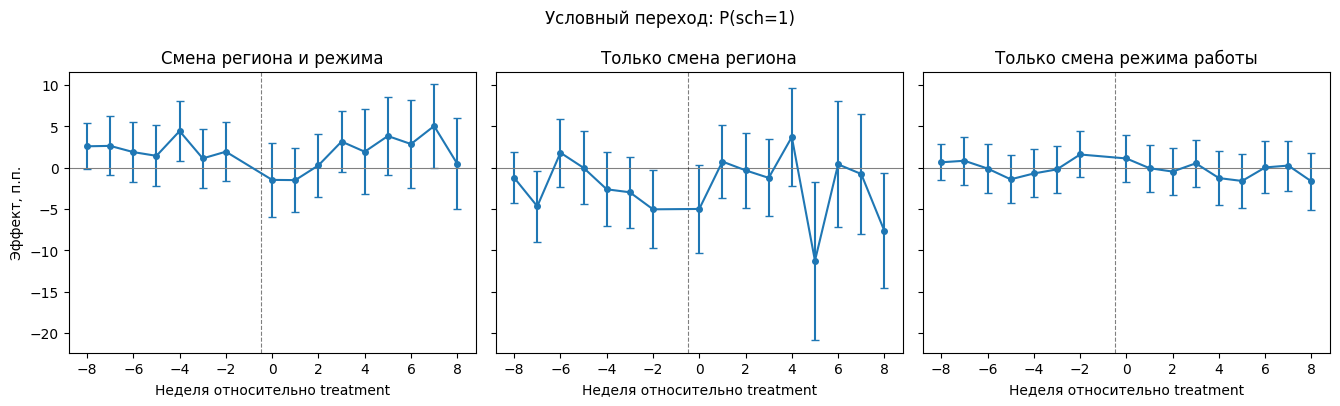

Saved: <PROJECT_ROOT>/…


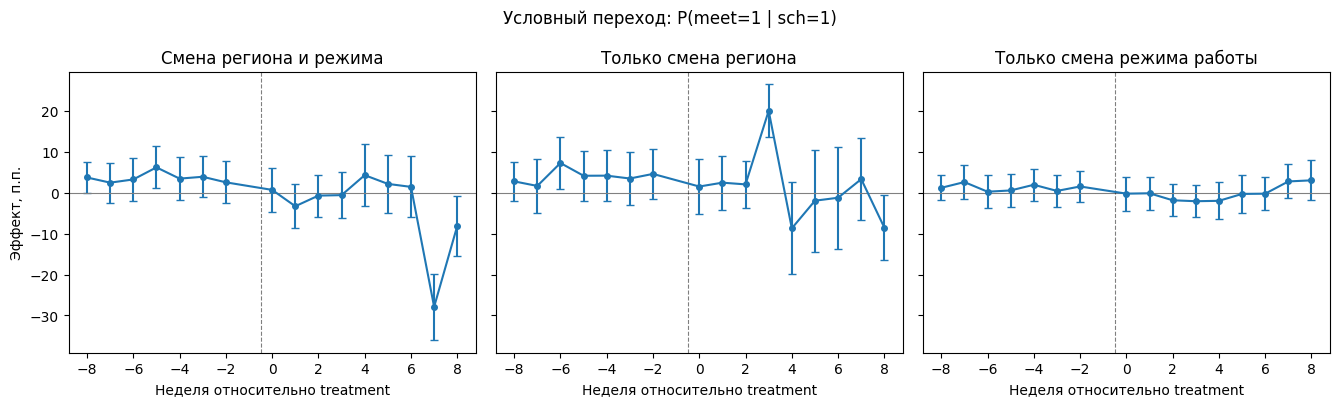

Saved: <PROJECT_ROOT>/…


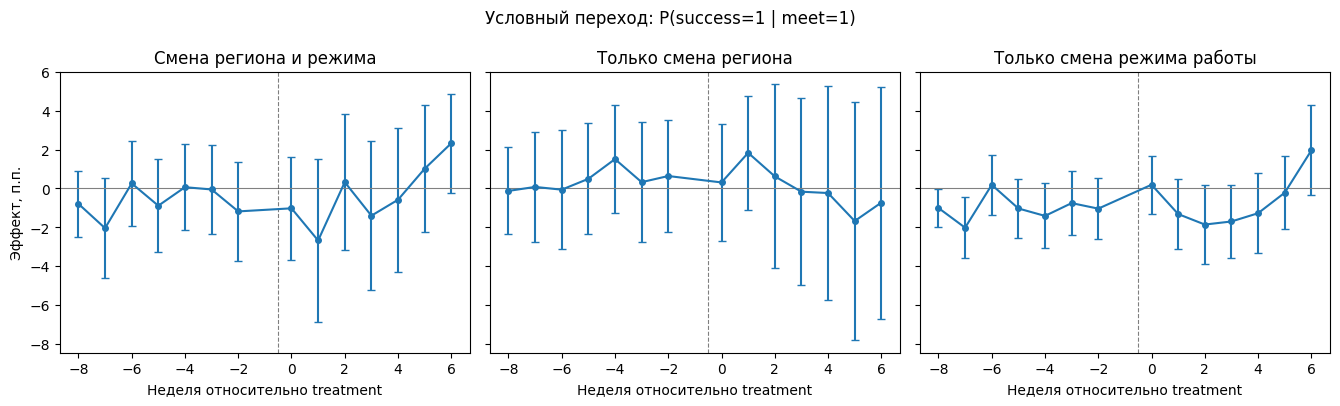

Saved: <PROJECT_ROOT>/…


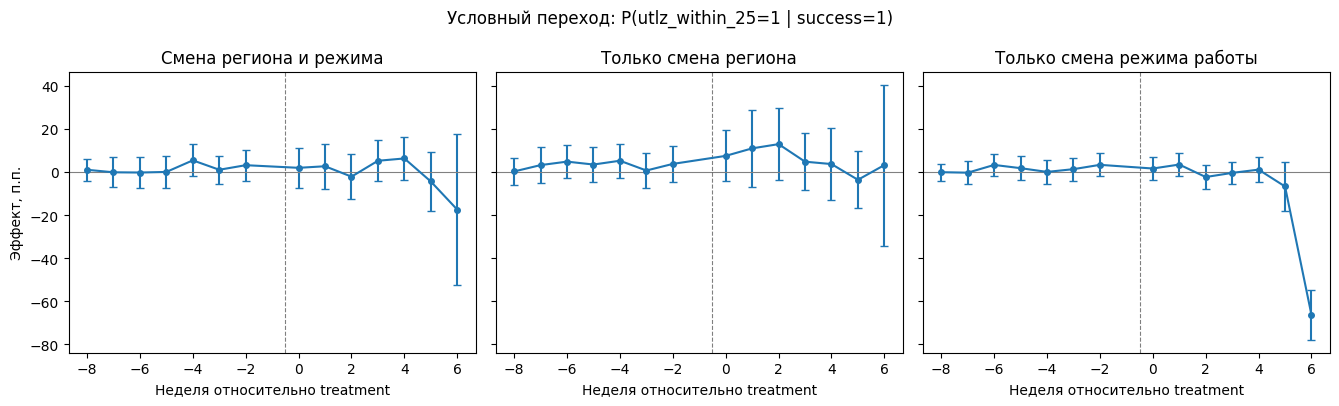

Saved: <PROJECT_ROOT>/…


In [7]:
# ============================================================
# 6. Графики event-study
# ============================================================

def plot_conditional_by_type(outcome_key: str, results_dict: dict, filename: str):
    spec = CONDITIONAL_OUTCOME_SPECS[outcome_key]
    fig, axes = plt.subplots(1, len(TYPE_ORDER), figsize=(13.5, 4.1), sharey=True)
    if len(TYPE_ORDER) == 1:
        axes = [axes]

    for ax, ctype in zip(axes, TYPE_ORDER):
        item = results_dict.get((outcome_key, ctype), {})
        coefs = item.get("coefs")
        if coefs is None or coefs.empty:
            ax.set_title(TYPE_LABELS[ctype])
            ax.axhline(0, color="gray", lw=0.8)
            continue
        est = coefs[coefs["estimated"]]
        ax.errorbar(
            est.index,
            est["coef"] * 100,
            yerr=[(est["coef"] - est["ci_low"]) * 100, (est["ci_high"] - est["coef"]) * 100],
            fmt="o-",
            capsize=3,
            ms=4,
        )
        ax.axhline(0, color="gray", lw=0.8)
        ax.axvline(-0.5, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_title(TYPE_LABELS[ctype])
        ax.set_xlabel("Неделя относительно treatment")
    axes[0].set_ylabel("Эффект, п.п.")
    fig.suptitle(f"Условный переход: {spec['label']}")
    fig.tight_layout()
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


for outcome_key in OUTCOMES_ORDER:
    plot_conditional_by_type(outcome_key, results, f"event_study_{outcome_key}.pdf")

## 6. Как читать результаты вместе с основным PanelOLS

1. **`sch_given_request`** совпадает с `sch_flg` в основном ноутбуке — первый этап воронки.
2. **`meet_given_sch`** отделяет эффект на явку от эффекта на назначение.
3. **`success20_given_meet`** и **`utlz_given_success20`** используют горизонты H=20 и H=25.
4. Условные эффекты не перемножаются в безусловный итог: оба блока читаются параллельно.
5. Ячейки с нулевым знаменателем исключены — для поздних этапов выборка уже, чем в безусловном PanelOLS.


## Вывод

Условные переходы повторяют направление безусловных оценок на ранних этапах, но доверительные интервалы для `meet_given_sch`, `success20_given_meet` и `utlz_given_success20` повсеместно включают ноль. Устойчивого изменения вероятности перехода на отдельном этапе воронки не установлено; блок следует читать совместно с основным PanelOLS.